## Assignment 2: $k$ Nearest Neighbor

### Do any four.

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
2. What is a confusion table/matrix? What does it help us understand about a model's performance? 
3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
4. What does the root mean squared error quantify about a particular model?
5. What are overfitting and underfitting? 
6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

ANSWERS

1. The difference between regression and classification is regression deals with a numeric
outcome while classification deals with a categorical outcome.

2. A confusion table/matrix is a way to cross-tabulate true labels with predicted labels.
It helps us understand which cases were correctly classified and which cases were incorrectly
classified, offering more insight into the accuracy of a model's performance.

3. Accuracy is the proportion of cases that were predicted correctly. It might not be entirely
sufficient to evaluate a classifier's predictive performance because it can perform very well on
training data, but be unreliable on new data.

4. Root mean squared error quantifies the distance from the true values to the predicted ones,
weighted by sample size, about a particular model.

5. Overfitting happens when the model is overly sensitive to a handful of data points due to picking a 
k value that is too low. Underfitting is when the model averages over many observations causing it 
to give answers close to population proportions as a result of picking a k value that is too high.

6. Splitting the data into training and testing sets, and choosing k by evaluating accuracy
or RMSE on the test set improves model performance by recreating how the model will respond to new
data, avoiding judging the model by its performance on training data and preventing overconfidence.

7. The strengths of reporting a class label as a prediction (hard classification) are 
it's easy to interpret and produces a clear final output. Its weaknesses are it doesn't show 
label proportions, leaving out important indicators. The strengths of reporting a class label as a 
probability distribution over class labels (soft classification) are it clearly displays how common each label is,
illustrating clear patterns. Its weaknesses are it's harder to interpret and doesn't produce a singular clear final output.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

count    338.000000
mean       2.952663
std        1.419703
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: mine_type, dtype: float64
count    338.000000
mean       0.430634
std        0.195819
min        0.197734
25%        0.309737
50%        0.359516
75%        0.482628
max        0.999999
Name: voltage, dtype: float64
count    338.000000
mean       0.508876
std        0.306043
min        0.000000
25%        0.272727
50%        0.545455
75%        0.727273
max        1.000000
Name: height, dtype: float64
count    338.000000
mean       0.503550
std        0.344244
min        0.000000
25%        0.200000
50%        0.600000
75%        0.800000
max        1.000000
Name: soil, dtype: float64


<Axes: xlabel='voltage', ylabel='soil'>

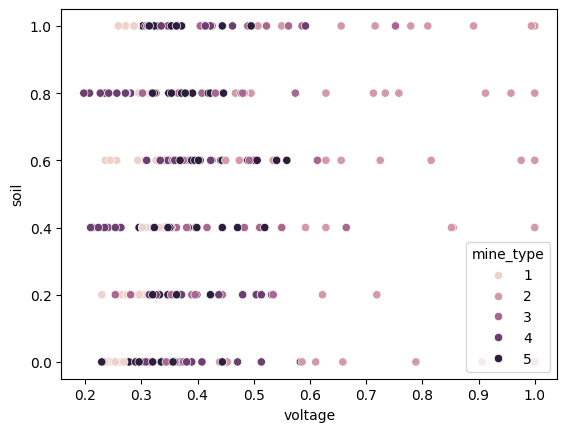

In [2]:
import pandas as pd 
import seaborn as sns

#2.1)
minesData = pd.read_csv("data/land_mines.csv")
print(minesData["mine_type"].describe())
print(minesData["voltage"].describe())
print(minesData["height"].describe())
print(minesData["soil"].describe())

sns.scatterplot(data = minesData, x = "voltage", y = "soil", hue = "mine_type")

<Axes: xlabel='voltage', ylabel='height'>

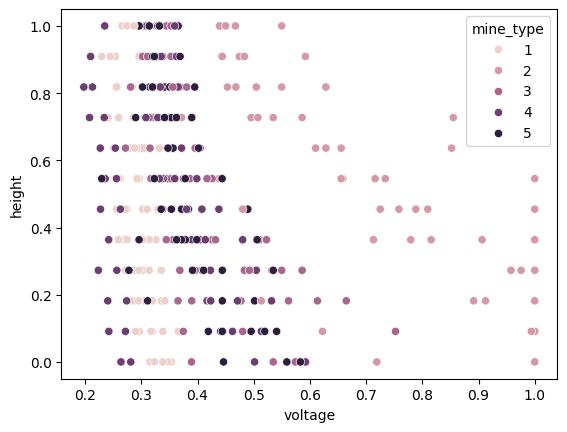

In [3]:
sns.scatterplot(data = minesData, x = "voltage", y = "height", hue = "mine_type")


<Axes: xlabel='height', ylabel='soil'>

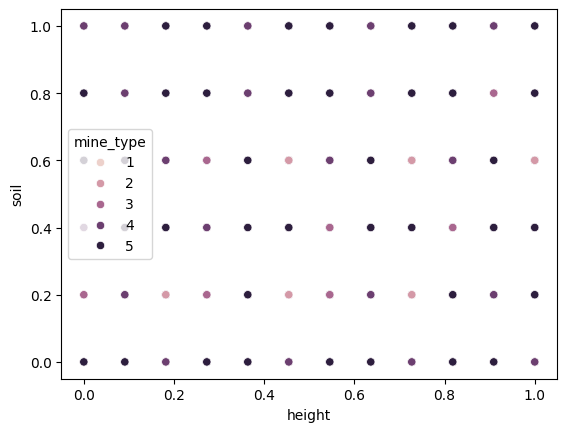

In [5]:
sns.scatterplot(data = minesData, x = "height", y = "soil", hue = "mine_type")

In [3]:
from sklearn.model_selection import train_test_split

#2.2)
y = minesData["mine_type"]
x = minesData[["voltage", "height", "soil"]]

def minmax(x):
    u = (x - min(x) / max(x) - min(x))
    return u
u = x.apply(minmax)
u_train, u_test, y_train, y_test = train_test_split(u, y, test_size = 0.5, random_state = 100)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

#2.3)
k_grid = [ (2*k+3) for k in range(0,15)]
testAccuracies = []
trainAccuracies = []
for k in k_grid:
    model = KNeighborsClassifier(n_neighbors = k)
    model = model.fit(u_train, y_train)
    testAccuracy = model.score(u_test, y_test)
    testAccuracies.append(testAccuracy)
    trainAccuracy = model.score(u_train, y_train)
    trainAccuracies.append(trainAccuracy)
    
indexValue = np.argmax(testAccuracies)
kValue = k_grid[indexValue]

#I selected k by looping over a range of values, appending accuracies to a list on each iteration.
#I then chose the largest value in the accuracies list and used that as the index to find my k value in the grid.

#2.4)
model = KNeighborsClassifier(n_neighbors = kValue)
model = model.fit(u_train, y_train)
y_hat = model.predict(u_test)
print(pd.crosstab(y_test, y_hat))
print(model.score(u_test, y_test))

#It is %39.64 accurate. Performance is more accurate for mines 1 and 2 and less 
#accurate for mines 3-5.

#2.5)
#Given the errors it tends to make, I would advise someone to actually use this predictive model in practice by using it only
#as supportive aid, using it to contribute to a final conclusion but not define it entirely. Other sources should be paired with it
#so an accurate interpretation can be produced.

col_0       1   2   3  4   5
mine_type                   
1          26   0  10  0   2
2           0  21   7  2   5
3           3   3   8  0  19
4          17   0   7  4   7
5           7   0  13  0   8
0.39644970414201186


**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

   price  year  mileage
0   6300  2008   274117
1   2899  2011   190552
2   5350  2018    39590
3  25000  2014    64146
4  27700  2018     6654
(2499, 3)
price      0
year       0
mileage    0
dtype: int64


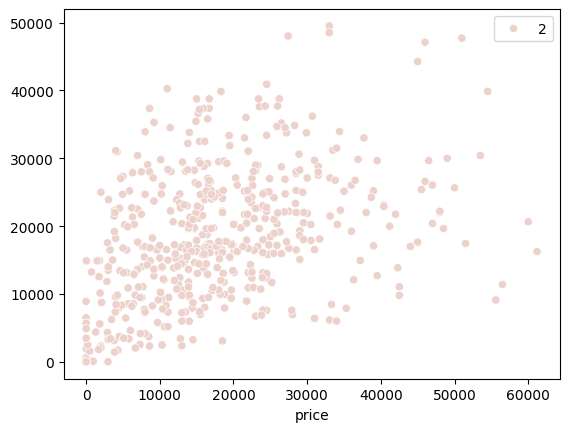

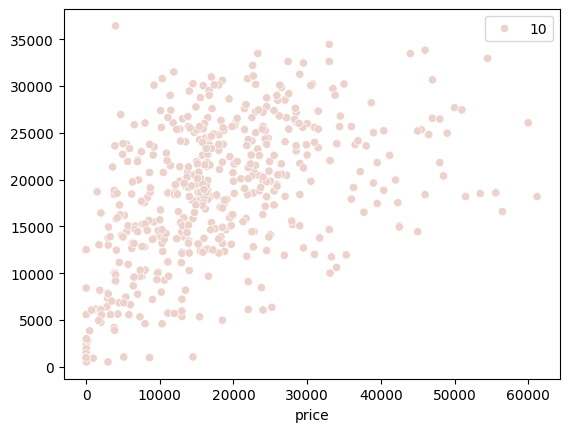

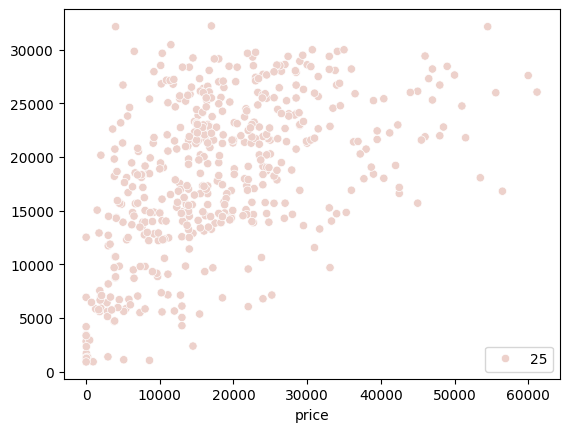

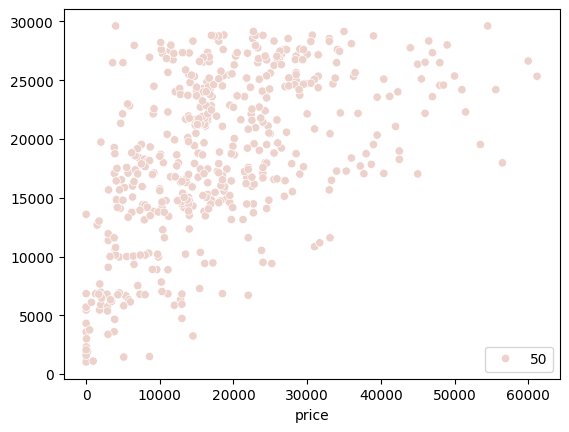

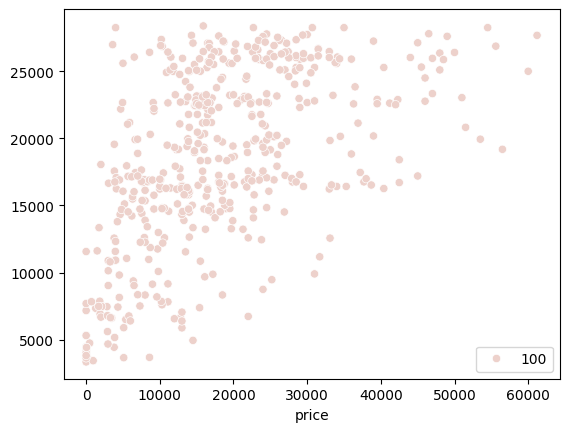

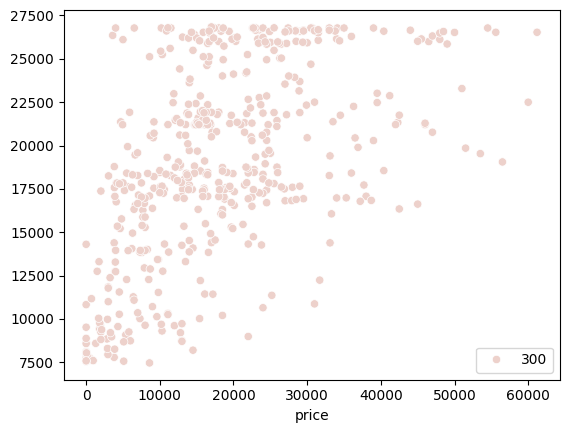

K Value:  100


In [ ]:
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#3.1)
carsData = pd.read_csv("data/USA_cars_datasets.csv")
carsData = carsData[["price", "year", "mileage"]]
print(carsData.head())
print(carsData.shape)
print(carsData.isna().sum())

#There are no NA's to handle.

#3.2)
def minMaxFunction(x):
    u = (x-min(x)) / (max(x) - min(x))
    return u

YearMileage = carsData[["year", "mileage"]]
price = carsData["price"]
u = YearMileage.apply(minMaxFunction)

#3.3)
u_train, u_test, y_train, y_test = train_test_split(u, price, test_size = 0.2, random_state = 100)

#3.4)
kVariables = [2, 10, 25, 50, 100, 300]
for k in kVariables:
    model = KNeighborsRegressor(n_neighbors = k)
    model = model.fit(u_train, y_train)
    y_hat = model.predict(u_test)
    meanSquaredError = mean_squared_error(y_test, y_hat)
    sns.scatterplot(x = y_test, y = y_hat, hue = k)
    plt.show()
    
#As I increase K the points begin to move towards the mean. The first couple K values illustrate
#overfitting while the central K values illustrate the cleanest distributions and the higher K values
#illustrate underfitting.

#3.5)
mses =[]
for k in kVariables:
    model = KNeighborsRegressor(n_neighbors = k)
    model = model.fit(u_train, y_train)
    y_hat = model.predict(u_test)
    meanSquaredError = mean_squared_error(y_test, y_hat)
    mses.append(meanSquaredError)
index = np.argmin(mses)
kValue = kVariables[index]
print("K Value: ", kValue)

#3.6) 
#As observed in 3.4, in the plots of predicted vs actual prices as K varied the plots showed 
#overfitting at smaller K values with points being overly sensitive and underfitting at higher K values with points
#being close to population proportions, making the central values optimal and justifying my choice of 100 as my K value.

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on. 

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

In [36]:
from sklearn.neighbors import KNeighborsClassifier

#5.1)
animalData = pd.read_csv("data/zoo.csv")
print(animalData.head())
print(animalData.describe())
print(animalData["class"].value_counts())

#I couldn't find an "animals.csv" anywhere in the data provided so I used "zoo.csv" which
#appears to have all the characteristics of the dataset this question is asking for. Class
#1 is size 41, class 2 size 20, class 3 size 5, class 4 size 13, class 5 size 4, class 6
#size 8, class 7 size 10. There is a decent amount of variation among the features/covariates.
#I think that the aquatic, airborne, milk, and eggs features will best predict each class.

#5.2)
classVariable = animalData["class"]
ctrl_list = ["hair", "feathers", "eggs", "milk", "airborne", "aquatic", "predator", "toothed", "backbone", "breathes", "venomous", "fins", "legs", "tail", "domestic", "catsize"]
features = animalData[ctrl_list]
u_train, u_test, y_train, y_test = train_test_split(features, classVariable, test_size = 0.5, random_state = 100)

#5.3
kGrid = np.array([(2 * k + 3) for k in range (0,14)])
accuracyArray = []
for k in kGrid:
    model = KNeighborsClassifier(n_neighbors = k)
    model = model.fit(u_train, y_train)
    accuracy = model.score(u_test, y_test)
    accuracyArray.append(accuracy)
index = np.argmax(accuracyArray)
kValue = kGrid[index]
print("K Value: ", kValue)

#I selected K by creating a grid with an odd range and looping over every K value, fitting it
#and scoring it, appending the accuracy score to an array each time. I then used the largest accuracy score
#in the array as an index into the grid, producing the best K value of 3.

#5.4)
model = KNeighborsClassifier(n_neighbors = kValue)
model = model.fit(u_train, y_train)
y_hat = model.predict(u_test)
print(pd.crosstab(y_test, y_hat))
print(model.score(u_test, y_test))

#The model is 88.24% accurate. Mistakes are made across groups because some of the classes 
#both have the same features, resulting in inaccuracies in the model.

#5.5)
newCtrl_list = ["milk", "aquatic", "airborne"]
newFeatures = animalData[newCtrl_list]
secondu_train, secondu_test, secondy_train, secondy_test = train_test_split(newFeatures, classVariable, test_size = 0.5, random_state = 100)
newModel = KNeighborsClassifier(n_neighbors = kValue)
newModel = model.fit(secondu_train, secondy_train)
newy_hat = model.predict(secondu_test)
print(pd.crosstab(secondy_test, newy_hat))
print(model.score(secondu_test, secondy_test))
probabilities = newModel.predict_proba(secondu_test.values)
print(probabilities)

#All the classes are not represented and this is seen through classes 3, 5, and 7 receiving
#0 values for probability throughout every row. Using only milk, aquatic, and airborne dropped
#accuracy to 66.67%, indicating that the use of just these three variables isn't enough to
#separate the animals.



     animal  hair  feathers  eggs  milk  airborne  aquatic  predator  toothed  \
0  aardvark     1         0     0     1         0        0         1        1   
1  antelope     1         0     0     1         0        0         0        1   
2      bass     0         0     1     0         0        1         1        1   
3      bear     1         0     0     1         0        0         1        1   
4      boar     1         0     0     1         0        0         1        1   

   backbone  breathes  venomous  fins  legs  tail  domestic  catsize  class  
0         1         1         0     0     4     0         0        1      1  
1         1         1         0     0     4     1         0        1      1  
2         1         0         0     1     0     1         0        0      4  
3         1         1         0     0     4     0         0        1      1  
4         1         1         0     0     4     1         0        1      1  
             hair    feathers        eggs    

C:\Users\jacka\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings. 
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5): 
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)